# AI and Advanced Analytics in UX Research



### Which method to use for which UX question?

| Method | UX question it answers | Data needed | Best use case | 
|---|---|---|---|
| TabPFN v2 (supervised) | Which users are likely to report poor experience or fail adoption? | Labeled tabular data (rows = users/sessions) | Small-to-medium UX prediction problems where fast strong baselines matter |
| Clustering (K-means / DBSCAN) | What behavioral segments exist in usage patterns? | Unlabeled behavioral features | Segment discovery, journey tailoring, intervention design |
| Anomaly detection | Which sessions look unusual and need investigation? | Mostly unlabeled telemetry, optionally sparse labels for evaluation | Proactive monitoring for severe friction, bot-like usage, release issues | 
| Time series analysis | How are UX metrics changing over time and what happens next? | Timestamped metric history | Redesign evaluation, trend detection, forecasting |


## Imports and Setup

In [30]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn statsmodels tabpfn

Note: you may need to restart the kernel to use updated packages.


In [31]:

# Importing libraries, setting random seeds, and configuring plot style.


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    silhouette_score,
    precision_score,
    recall_score,
    mean_absolute_error,
    mean_squared_error,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Section 1: Tabular Foundation Models with TabPFN v2

### Business or UX decision context
A product team wants to identify users likely to report a **poor experience after onboarding**, so they can intervene early with guided help, usability fixes, or proactive support.

We will compare TabPFN v2 to a baseline logistic regression model.

In [32]:

# Can we predict which users will report a poor onboarding experience?


from pathlib import Path

tabpfn_csv = Path("ux_tabpfn_dataset.csv")
if not tabpfn_csv.exists():
    raise FileNotFoundError("ux_tabpfn_dataset.csv not found. Ensure the file is in the notebook working directory.")

ux_tabular_df = pd.read_csv(tabpfn_csv)

print("Loaded:", tabpfn_csv.resolve())
print("Shape:", ux_tabular_df.shape)
print("\nFirst 5 rows:")
display(ux_tabular_df.head())
print("\nSummary stats (numeric):")
display(ux_tabular_df.describe().T)
print("\nTarget balance (poor_experience=1):")
print(ux_tabular_df["poor_experience"].value_counts(normalize=True).rename("proportion").round(3))


Loaded: /Users/mohsen/Desktop/AI Quant UX/ux_tabpfn_dataset.csv
Shape: (900, 15)

First 5 rows:


,age,device_type,user_type,prior_experience,traffic_source,session_duration,time_on_task,scroll_depth,feature_usage_count,help_page_visits,error_count,frustration_proxy,task_success,usability_score,poor_experience
0,22,mobile,returning,medium,organic,7.96,3.10,48.04,3,3,1,1.66,0,74.38,0
1,55,desktop,returning,medium,referral,14.93,5.57,61.24,6,3,2,3.27,1,78.11,0
2,49,desktop,new,medium,paid,8.48,5.91,71.44,7,3,0,1.42,0,95.49,0
3,39,mobile,new,medium,organic,7.68,6.83,5.00,3,2,0,0.84,1,74.78,0
4,38,mobile,returning,high,organic,16.24,2.71,100.00,6,1,3,1.73,1,80.17,0



Summary stats (numeric):


,count,mean,std,min,25%,50%,75%,max
age,900.0,41.738889,14.016820,18.00,29.0000,42.000,54.0000,65.00
session_duration,900.0,10.918389,3.956758,1.00,8.2375,10.875,13.3275,24.82
time_on_task,900.0,7.540933,2.948572,0.50,5.4775,7.605,9.4825,17.22
scroll_depth,900.0,65.708178,19.677172,5.00,53.0725,64.845,80.1525,100.00
feature_usage_count,900.0,5.010000,2.250426,0.00,3.0000,5.000,6.0000,14.00
help_page_visits,900.0,1.301111,1.104848,0.00,0.0000,1.000,2.0000,6.00
error_count,900.0,1.120000,1.072998,0.00,0.0000,1.000,2.0000,7.00
frustration_proxy,900.0,1.158289,1.092209,-2.01,0.4600,1.160,1.8100,6.69
task_success,900.0,0.795556,0.403519,0.00,1.0000,1.000,1.0000,1.00
usability_score,900.0,79.418078,8.560134,48.79,73.7000,79.665,85.5975,100.00



Target balance (poor_experience=1):
poor_experience
0    0.994
1    0.006
Name: proportion, dtype: float64



Baseline classification report:

              precision    recall  f1-score   support

           0      0.996     1.000     0.998       224
           1      0.000     0.000     0.000         1

    accuracy                          0.996       225
   macro avg      0.498     0.500     0.499       225
weighted avg      0.991     0.996     0.993       225


TabPFN classification report:

              precision    recall  f1-score   support

           0      0.996     1.000     0.998       224
           1      0.000     0.000     0.000         1

    accuracy                          0.996       225
   macro avg      0.498     0.500     0.499       225
weighted avg      0.991     0.996     0.993       225


Model comparison table:


,Model,Accuracy,F1,ROC_AUC
0,Logistic Regression,0.996,0.000,0.951
1,TabPFN v2,0.996,0.000,0.946


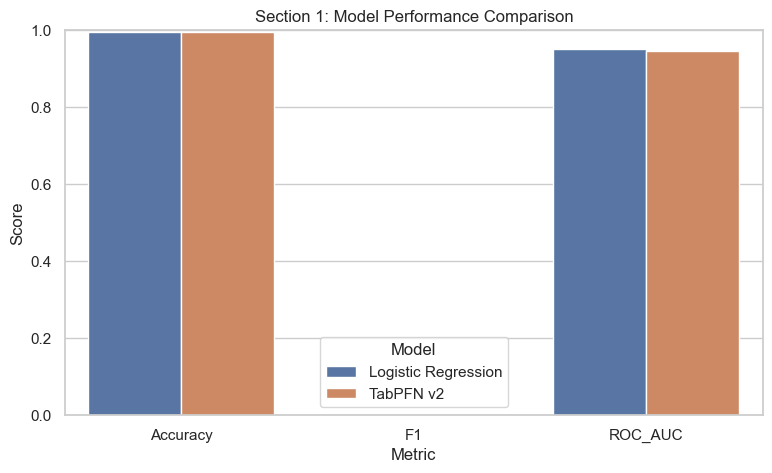

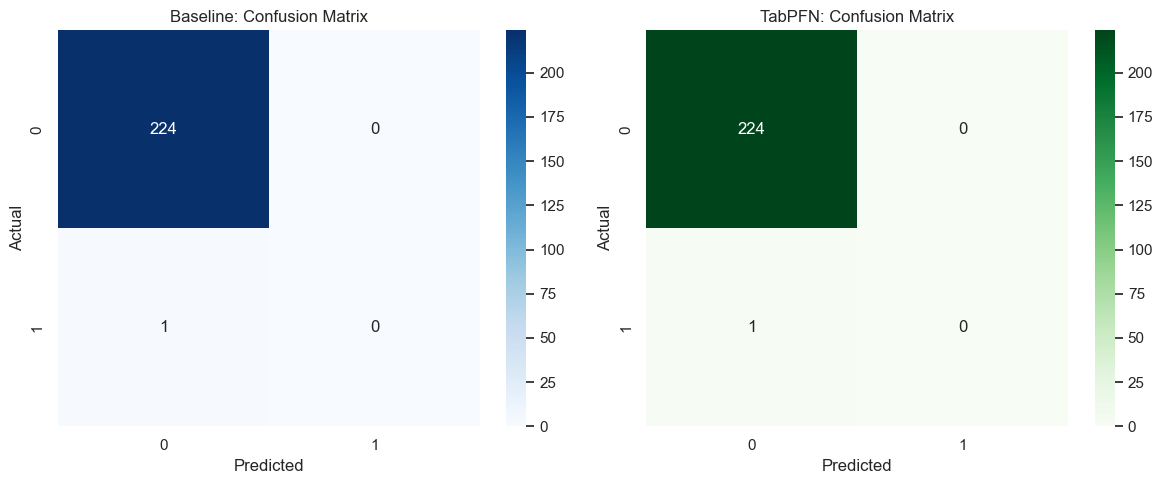

Top 10 users by predicted risk using TabPFN:


,age,device_type,user_type,prior_experience,traffic_source,session_duration,time_on_task,scroll_depth,feature_usage_count,help_page_visits,error_count,frustration_proxy,task_success,usability_score,actual_poor_experience,predicted_risk
95,31,mobile,new,low,referral,10.60,5.01,86.46,2,2,5,3.90,0,59.68,0,0.344301
47,60,desktop,returning,low,organic,19.96,8.05,87.36,3,3,4,4.33,1,68.44,0,0.166251
472,38,desktop,new,medium,paid,10.25,9.08,51.74,3,6,2,1.23,0,69.48,0,0.087552
503,59,mobile,returning,low,organic,11.85,7.10,45.33,3,5,1,2.02,0,72.05,0,0.067843
270,32,mobile,new,low,direct,12.59,8.94,66.78,4,3,2,3.30,0,78.70,0,0.067465
157,44,mobile,new,low,organic,13.19,12.52,61.93,1,3,3,2.84,1,70.99,0,0.059463
139,38,mobile,new,low,paid,3.94,10.73,60.67,6,2,5,2.00,1,58.99,0,0.039147
135,32,desktop,new,medium,referral,11.25,7.30,99.12,3,2,4,3.33,1,61.93,0,0.029209
860,64,mobile,returning,low,organic,18.52,7.48,66.63,3,5,1,3.05,1,72.08,0,0.027442
738,53,mobile,returning,low,direct,10.52,8.88,67.36,6,0,3,4.12,1,62.11,0,0.024170


In [33]:

# How well does TabPFN predict poor experience versus a simpler baseline?
# Compare Accuracy, F1, ROC AUC, confusion matrices, and top-risk users by predicted probability.


feature_cols_1 = [c for c in ux_tabular_df.columns if c != "poor_experience"]
X1 = ux_tabular_df[feature_cols_1].copy()
y1 = ux_tabular_df["poor_experience"].copy()

cat_cols_1 = ["device_type", "user_type", "prior_experience", "traffic_source"]
num_cols_1 = [c for c in feature_cols_1 if c not in cat_cols_1]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.25, random_state=SEED, stratify=y1
)

# Baseline pipeline: one-hot + logistic regression.
baseline_pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("num", StandardScaler(), num_cols_1),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_1),
    ])),
    ("model", LogisticRegression(max_iter=2000, random_state=SEED)),
])

baseline_pipe.fit(X1_train, y1_train)
baseline_pred = baseline_pipe.predict(X1_test)
baseline_proba = baseline_pipe.predict_proba(X1_test)[:, 1]

results_1 = []
results_1.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y1_test, baseline_pred),
    "F1": f1_score(y1_test, baseline_pred),
    "ROC_AUC": roc_auc_score(y1_test, baseline_proba),
})

print("\nBaseline classification report:\n")
print(classification_report(y1_test, baseline_pred, digits=3))
# Interpretation tip:
# - F1 is useful when the "poor experience" class is not perfectly balanced.
# - ROC_AUC closer to 1.0 means better ranking of risky users.

# TabPFN section with graceful fallback if environment limitations exist.
tabpfn_available = False
tabpfn_pred = None
tabpfn_proba = None

try:
    from tabpfn import TabPFNClassifier

    # TabPFN expects numeric inputs; we use ordinal encoding for categoricals.
    tabpfn_encoder = ColumnTransformer([
        ("num", "passthrough", num_cols_1),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols_1),
    ])

    X1_train_tab = tabpfn_encoder.fit_transform(X1_train)
    X1_test_tab = tabpfn_encoder.transform(X1_test)

    tabpfn_model = TabPFNClassifier(device="cpu", random_state=SEED)
    tabpfn_model.fit(X1_train_tab, y1_train.values)

    tabpfn_pred = tabpfn_model.predict(X1_test_tab)
    tabpfn_proba = tabpfn_model.predict_proba(X1_test_tab)[:, 1]

    results_1.append({
        "Model": "TabPFN v2",
        "Accuracy": accuracy_score(y1_test, tabpfn_pred),
        "F1": f1_score(y1_test, tabpfn_pred),
        "ROC_AUC": roc_auc_score(y1_test, tabpfn_proba),
    })
    tabpfn_available = True

    print("\nTabPFN classification report:\n")
    print(classification_report(y1_test, tabpfn_pred, digits=3))
    # Interpretation tip:
    # If TabPFN improves ROC_AUC or F1, it is often better for prioritizing at-risk users.

except Exception as e:
    print("\nTabPFN could not run in this environment.")
    print("Reason:", str(e))
    print("You can still teach the workflow with the baseline and rerun TabPFN on a supported setup.")

results_1_df = pd.DataFrame(results_1)
print("\nModel comparison table:")
display(results_1_df.style.format({"Accuracy": "{:.3f}", "F1": "{:.3f}", "ROC_AUC": "{:.3f}"}))
# Interpretation tip:
# - Accuracy can hide minority-class misses.
# - Prefer F1 + ROC_AUC for UX risk detection quality.

# Visual 1: metric comparison bar chart.
results_melt = results_1_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(9, 5))
sns.barplot(data=results_melt, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1)
plt.title("Section 1: Model Performance Comparison")
plt.show()
# Interpretation tip:
# Taller bars indicate stronger performance for that metric.

# Visual 2: confusion matrices.
fig, axes = plt.subplots(1, 2 if tabpfn_available else 1, figsize=(12 if tabpfn_available else 6, 5))
if not tabpfn_available:
    axes = [axes]

cm_base = confusion_matrix(y1_test, baseline_pred)
sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Baseline: Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

if tabpfn_available:
    cm_tab = confusion_matrix(y1_test, tabpfn_pred)
    sns.heatmap(cm_tab, annot=True, fmt="d", cmap="Greens", ax=axes[1])
    axes[1].set_title("TabPFN: Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()
# Interpretation tip:
# - Bottom-left cell = false negatives (missed risky users): usually costly in UX.
# - Top-right cell = false positives: may create unnecessary interventions.

# Operational UX step: prioritize high-risk users based on predicted probabilities.
risk_scores = X1_test.copy()
risk_scores["actual_poor_experience"] = y1_test.values
if tabpfn_available:
    risk_scores["predicted_risk"] = tabpfn_proba
    risk_model_name = "TabPFN"
else:
    risk_scores["predicted_risk"] = baseline_proba
    risk_model_name = "Logistic Regression (fallback)"

risk_scores = risk_scores.sort_values("predicted_risk", ascending=False)
print(f"Top 10 users by predicted risk using {risk_model_name}:")
display(risk_scores.head(10))
# Interpretation tip:
# Focus design/support triage on high predicted-risk users first.



The model learns that combinations like **high error count + many help visits + low usability score + new user status** are strong indicators of poor onboarding experience.

If TabPFN runs successfully, it often performs very strongly on this kind of modest-size tabular UX dataset with less tuning work. Even when a fallback baseline is used, the workflow still demonstrates how to rank users by risk and target qualitative follow-ups.


## Section 2: Clustering with K-means and DBSCAN

### Business or UX decision context
A growth + UX team wants to segment users by **behavioral engagement patterns** (not just demographics) to design better journeys, onboarding nudges, and retention strategies.

### Method framing
- **K-means** is useful when you expect compact, roughly spherical groups and want clear segment assignments.
- **DBSCAN** is useful when clusters are irregular or when you care about identifying noise/outlier sessions.
- In UX work, behavior-based segments often reveal opportunities that demographic cuts miss.

In [34]:

# Are there meaningful behavioral user segments in product usage data?


from pathlib import Path

cluster_csv = Path("ux_clustering_dataset.csv")
if not cluster_csv.exists():
    raise FileNotFoundError("ux_clustering_dataset.csv not found. Ensure the file is in the notebook working directory.")

ux_cluster_df = pd.read_csv(cluster_csv)

print("Loaded:", cluster_csv.resolve())
print("Shape:", ux_cluster_df.shape)
print("\nFirst 5 rows:")
display(ux_cluster_df.head())


Loaded: /Users/mohsen/Desktop/AI Quant UX/ux_clustering_dataset.csv
Shape: (1100, 12)

First 5 rows:


,sessions_per_week,avg_session_duration,feature_diversity,task_completion_rate,error_rate,help_usage,retention_probability,scroll_depth,click_frequency,abandoned_flows,support_contacts,engagement_score
0,7.261075,18.506924,7.211645,0.938944,0.052160,0.719375,0.925332,69.334776,46.645744,0.408143,0.000000,142.218954
1,8.863759,23.538848,8.088333,0.942857,0.077334,0.130633,0.963437,69.690336,56.992342,0.091467,0.467557,166.760512
2,8.404223,15.782804,4.544937,0.899275,0.109959,0.047328,0.891370,68.553162,54.276874,0.372963,0.475626,136.001442
3,8.358454,14.720531,6.400525,0.976956,0.072646,0.577343,0.833664,81.214400,56.446747,0.999685,0.188667,145.190306
4,8.985178,22.212789,6.019087,0.988958,0.006497,0.788464,0.853840,82.368381,54.546694,1.676543,0.161933,156.568520


In [35]:

# Running quick data quality checks and applying minimal cleaning.


print("Missing values per column:")
display(ux_cluster_df.isna().sum().to_frame("missing_count").T)
print("Duplicate rows:", ux_cluster_df.duplicated().sum())

# Minimal cleaning: drop duplicates if any and enforce expected numeric dtypes.
ux_cluster_df = ux_cluster_df.drop_duplicates().copy()
for c in ux_cluster_df.columns:
    ux_cluster_df[c] = pd.to_numeric(ux_cluster_df[c], errors="coerce")

print("Shape after cleaning:", ux_cluster_df.shape)
print("Any missing after type coercion?", ux_cluster_df.isna().any().any())

Missing values per column:


,sessions_per_week,avg_session_duration,feature_diversity,task_completion_rate,error_rate,help_usage,retention_probability,scroll_depth,click_frequency,abandoned_flows,support_contacts,engagement_score
missing_count,0,0,0,0,0,0,0,0,0,0,0,0


Duplicate rows: 0
Shape after cleaning: (1100, 12)
Any missing after type coercion? False


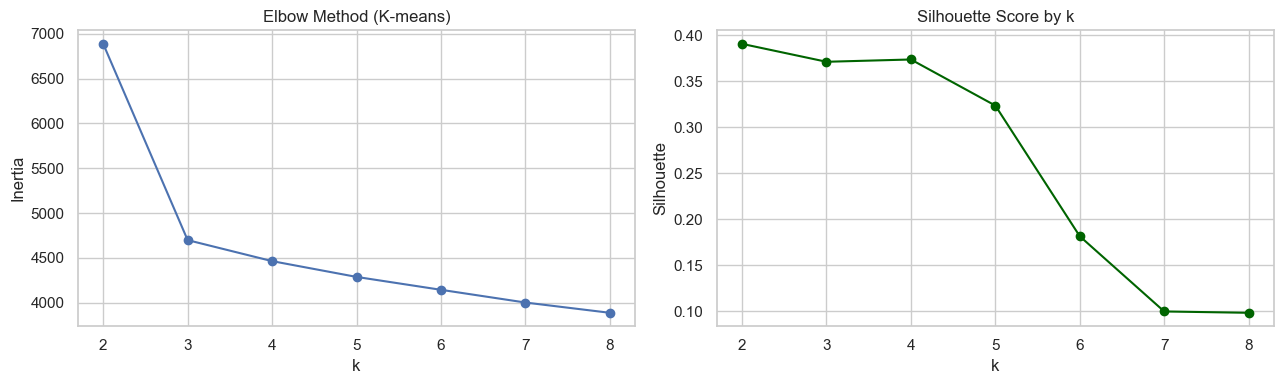

Best k by silhouette: 2

K-means cluster sizes:
kmeans_cluster
0    648
1    452
Name: count, dtype: int64

K-means cluster profile (means):


,sessions_per_week,avg_session_duration,feature_diversity,task_completion_rate,error_rate,help_usage,retention_probability,scroll_depth,click_frequency,abandoned_flows,support_contacts,engagement_score
kmeans_cluster,,,,,,,,,,,,
0,3.58,9.42,3.84,0.67,0.21,1.62,0.56,54.37,32.57,2.77,1.22,66.09
1,8.38,17.55,7.35,0.90,0.08,0.63,0.85,78.23,54.76,0.85,0.33,148.83


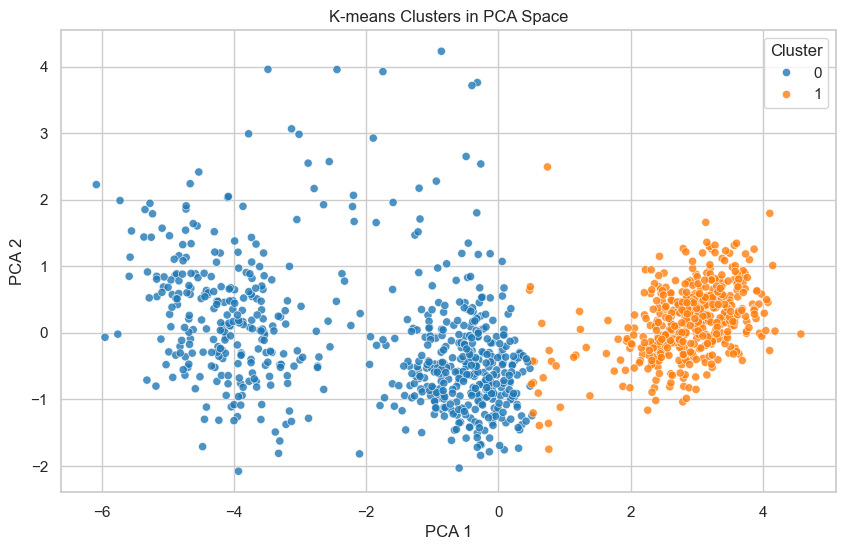

In [36]:

# How many behavioral segments exist and what characterizes each segment?
#
# Why is this method useful in UX research?
# It helps researchers move from average user metrics to segment-specific strategy.


cluster_features = [
    "sessions_per_week", "avg_session_duration", "feature_diversity", "task_completion_rate",
    "error_rate", "help_usage", "retention_probability", "scroll_depth", "click_frequency",
    "abandoned_flows", "support_contacts", "engagement_score"
]

X2 = ux_cluster_df[cluster_features].copy()
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

k_values = list(range(2, 9))
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels_k = km.fit_predict(X2_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X2_scaled, labels_k))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(k_values, inertias, marker="o")
ax[0].set_title("Elbow Method (K-means)")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_values, sil_scores, marker="o", color="darkgreen")
ax[1].set_title("Silhouette Score by k")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()
# Interpretation tip:
# - Elbow: look for where inertia reduction starts flattening.
# - Silhouette: higher is better-separated clusters.

best_k = k_values[int(np.argmax(sil_scores))]
print("Best k by silhouette:", best_k)

kmeans_model = KMeans(n_clusters=best_k, random_state=SEED, n_init=20)
ux_cluster_df["kmeans_cluster"] = kmeans_model.fit_predict(X2_scaled)

print("\nK-means cluster sizes:")
print(ux_cluster_df["kmeans_cluster"].value_counts().sort_index())
# Interpretation tip:
# Very tiny clusters can be unstable; treat with caution in business decisions.

cluster_profile = ux_cluster_df.groupby("kmeans_cluster")[cluster_features].mean().round(2)
print("\nK-means cluster profile (means):")
display(cluster_profile)
# Interpretation tip:
# Convert each cluster profile into a persona-like label (e.g., "high engagement", "struggling").

# PCA for simple 2D teaching visualization.
pca2 = PCA(n_components=2, random_state=SEED)
X2_pca = pca2.fit_transform(X2_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X2_pca[:, 0], y=X2_pca[:, 1], hue=ux_cluster_df["kmeans_cluster"], palette="tab10", s=35, alpha=0.8)
plt.title("K-means Clusters in PCA Space")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.show()
# Interpretation tip:
# If colors overlap heavily, clusters may not be strongly separable in behavior space.


DBSCAN label counts (-1 means noise):
dbscan_cluster
-1    914
 0    186
Name: count, dtype: int64


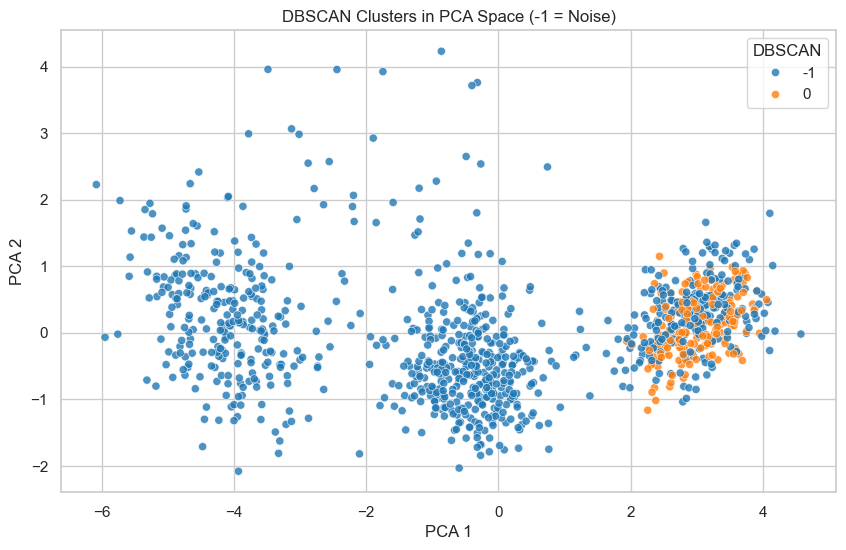


Number of DBSCAN noise points: 914
Example noise points (potential unusual behavior cases):


,sessions_per_week,avg_session_duration,feature_diversity,task_completion_rate,error_rate,help_usage,retention_probability,scroll_depth,click_frequency,abandoned_flows,support_contacts,engagement_score,kmeans_cluster,dbscan_cluster
2,8.404223,15.782804,4.544937,0.899275,0.109959,0.047328,0.891370,68.553162,54.276874,0.372963,0.475626,136.001442,1,-1
8,6.794016,21.937043,7.304237,0.908967,0.063312,0.459769,0.911860,77.035057,67.298782,0.959768,0.471308,142.000816,1,-1
9,9.367086,13.873674,6.755958,0.885452,0.041466,1.372676,0.882298,81.382562,64.080552,0.000000,0.000000,146.933511,1,-1
12,10.469776,18.789679,6.423190,0.933024,0.149056,0.586915,0.944006,84.999759,50.352404,0.000000,0.197010,161.367370,1,-1
13,6.051057,22.972437,6.921228,0.906964,0.105819,0.502747,0.813966,88.209927,63.696566,1.561919,0.000000,133.248197,1,-1
15,7.478530,15.428013,8.384254,0.861389,0.018554,0.489841,0.976595,71.383642,55.777787,1.186287,0.000000,146.501864,1,-1
17,8.151422,8.358222,7.065372,0.877052,0.063740,0.600696,0.793494,89.208687,54.764465,1.124825,0.661760,137.307648,1,-1
20,12.733610,15.660295,8.997011,0.899211,0.098185,0.334942,0.858419,84.387976,49.018242,1.560305,0.294300,191.470523,1,-1
21,6.304886,21.628516,5.328477,0.920128,0.081334,0.396853,0.879732,100.494728,50.316864,0.000000,0.000000,128.124470,1,-1
22,7.950310,11.877168,9.970350,0.943807,0.092108,0.818238,0.877080,66.342227,63.101969,1.320268,0.828209,153.762747,1,-1



K-means vs DBSCAN cross-tab:


dbscan_cluster,-1,0
kmeans_cluster,,
0,648,0
1,266,186


In [37]:

# Why is this method useful in UX research?
# DBSCAN can flag non-conforming behavioral patterns that K-means may force into clusters.


dbscan_model = DBSCAN(eps=1.15, min_samples=14)
ux_cluster_df["dbscan_cluster"] = dbscan_model.fit_predict(X2_scaled)

print("DBSCAN label counts (-1 means noise):")
print(ux_cluster_df["dbscan_cluster"].value_counts().sort_index())
# Interpretation tip:
# - More -1 points => stricter density definition or more unusual sessions.

plt.figure(figsize=(10, 6))
palette = sns.color_palette("tab10", n_colors=max(ux_cluster_df["dbscan_cluster"].nunique(), 3))
sns.scatterplot(
    x=X2_pca[:, 0], y=X2_pca[:, 1], hue=ux_cluster_df["dbscan_cluster"],
    palette=palette, s=35, alpha=0.8
)
plt.title("DBSCAN Clusters in PCA Space (-1 = Noise)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="DBSCAN")
plt.show()
# Interpretation tip:
# Gray/outlier-looking points in sparse areas are often edge-case user journeys.

noise_df = ux_cluster_df[ux_cluster_df["dbscan_cluster"] == -1].copy()
print(f"\nNumber of DBSCAN noise points: {len(noise_df)}")
if len(noise_df) > 0:
    print("Example noise points (potential unusual behavior cases):")
    display(noise_df.head(10))
# Interpretation tip:
# Review noise sessions for severe friction, bots, power-user edge behavior, or logging issues.

# Side-by-side comparison table.
comparison_table = pd.crosstab(ux_cluster_df["kmeans_cluster"], ux_cluster_df["dbscan_cluster"])
print("\nK-means vs DBSCAN cross-tab:")
display(comparison_table)
# Interpretation tip:
# If one K-means cluster maps to multiple DBSCAN groups, behavior may be non-spherical or mixed.


### Section 2 Interpretation

K-means gives clean, stable segments that are easy to communicate to stakeholders (for example: high engagement, mainstream, struggling). DBSCAN adds value by identifying points that do not belong to dense behavior groups, which can reveal unusual journeys, possible edge-case pain points, or instrumentation issues.

- Use **K-means** when you want clear segment partitions and compact groups.
- Use **DBSCAN** when you expect irregular structures or need explicit noise detection.
- Behavioral segmentation is often more actionable for UX than demographic segmentation alone.

## Section 3: Anomaly Detection in UX Data

### Business or UX decision context
After a recent release, the UX analytics team wants to detect unusual sessions that may indicate severe usability friction, bot-like activity, broken flows, or technical instability.

### Why anomalies matter in UX analytics
- They can signal high-impact but rare issues hidden by average metrics.
- Unlike normal supervised classification, anomaly detection often works with **little or no labels**.
- Even unlabeled telemetry can still support proactive monitoring by flagging suspicious sessions for review.

Loaded: /Users/mohsen/Desktop/AI Quant UX/ux_anomaly_dataset.csv
Shape: (2200, 15)
True anomaly rate: 0.05


,session_duration,rage_clicks,form_retries,error_messages,latency_ms,screen_transitions,help_page_visits,crash_indicator,scroll_depth,task_completion,input_hesitation_sec,backtracking_count,api_response_ms,support_escalation_proxy,is_anomaly
0,15.441726,1,1,2,400.793953,15.689681,1,0,54.270606,1,2.679467,1,256.994234,0,0
1,14.524282,0,0,1,205.529976,7.073003,2,0,64.943561,1,3.023240,1,264.870390,0,0
2,7.775296,0,0,1,343.333592,19.801895,3,0,65.378826,1,2.714213,1,142.863530,0,0
3,5.800696,0,1,2,406.552622,9.813731,1,0,81.704026,1,2.881943,3,259.418729,0,0
4,9.102741,1,0,0,316.873612,16.878479,1,0,100.000000,1,0.644664,1,277.496140,1,0


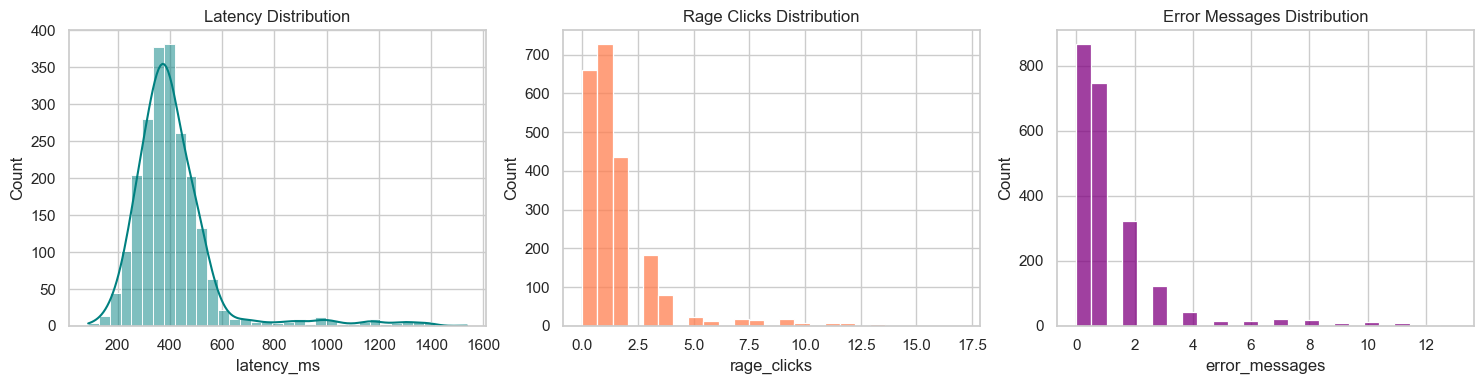

In [38]:

# Which sessions are abnormally risky and should be inspected by UX researchers?


from pathlib import Path

anomaly_csv = Path("ux_anomaly_dataset.csv")
if not anomaly_csv.exists():
    raise FileNotFoundError("ux_anomaly_dataset.csv not found. Ensure the file is in the notebook working directory.")

ux_anomaly_df = pd.read_csv(anomaly_csv)

print("Loaded:", anomaly_csv.resolve())
print("Shape:", ux_anomaly_df.shape)
print("True anomaly rate:", ux_anomaly_df["is_anomaly"].mean().round(3))
display(ux_anomaly_df.head())

# Quick distribution visuals to motivate anomaly detection.
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(ux_anomaly_df["latency_ms"], bins=35, kde=True, ax=ax[0], color="teal")
ax[0].set_title("Latency Distribution")
sns.histplot(ux_anomaly_df["rage_clicks"], bins=25, kde=False, ax=ax[1], color="coral")
ax[1].set_title("Rage Clicks Distribution")
sns.histplot(ux_anomaly_df["error_messages"], bins=25, kde=False, ax=ax[2], color="purple")
ax[2].set_title("Error Messages Distribution")
plt.tight_layout()
plt.show()


In [39]:

print("Missing values per column:")
display(ux_anomaly_df.isna().sum().to_frame("missing_count").T)
print("Duplicate rows:", ux_anomaly_df.duplicated().sum())

ux_anomaly_df = ux_anomaly_df.drop_duplicates().copy()
ux_anomaly_df = ux_anomaly_df.fillna(ux_anomaly_df.median(numeric_only=True))

print("Shape after cleaning:", ux_anomaly_df.shape)
print("Any missing values left?", ux_anomaly_df.isna().any().any())

Missing values per column:


,session_duration,rage_clicks,form_retries,error_messages,latency_ms,screen_transitions,help_page_visits,crash_indicator,scroll_depth,task_completion,input_hesitation_sec,backtracking_count,api_response_ms,support_escalation_proxy,is_anomaly
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Duplicate rows: 0
Shape after cleaning: (2200, 15)
Any missing values left? False


Anomaly detection performance (using hidden labels only for evaluation):


,Model,Precision,Recall,F1,Accuracy
0,Isolation Forest,1.000,1.000,1.000,1.000
1,Local Outlier Factor,0.018,0.018,0.018,0.902



Isolation Forest confusion matrix:
[[2090    0]
 [   0  110]]

Local Outlier Factor confusion matrix:
[[1982  108]
 [ 108    2]]


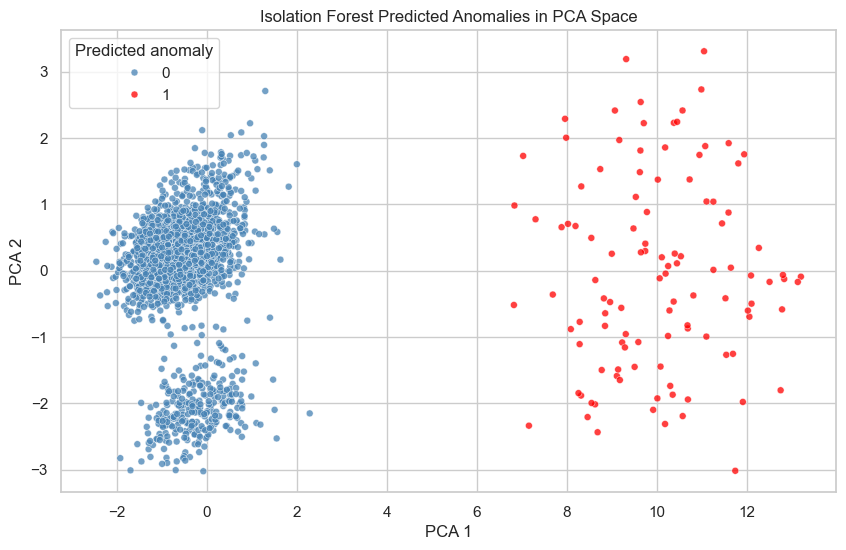

Top 12 most abnormal sessions (Isolation Forest):


,session_duration,rage_clicks,form_retries,error_messages,latency_ms,screen_transitions,help_page_visits,crash_indicator,scroll_depth,task_completion,input_hesitation_sec,backtracking_count,api_response_ms,support_escalation_proxy,is_anomaly,iso_anomaly_score,iso_predicted_anomaly
1131,23.546300,13,12,4,646.580468,1.850343,5,1,0.000000,0,5.076003,8,505.617622,1,1,0.722885,1
20,32.117670,11,6,6,1181.024074,1.000000,6,1,60.079843,0,6.195573,3,1356.076879,1,1,0.721621,1
1088,24.707554,7,9,8,1265.403296,8.637124,11,0,9.911172,0,6.237077,8,678.195886,1,1,0.720980,1
1586,27.827073,6,7,11,769.936909,10.387663,3,1,71.967020,0,4.814349,10,852.452568,1,1,0.719083,1
1421,21.630435,13,2,5,867.009244,4.234234,6,1,80.929735,1,5.495007,8,626.128831,1,1,0.718384,1
36,14.271562,12,6,6,1345.080797,13.202729,7,1,54.228698,1,5.445705,5,806.280017,1,1,0.717886,1
1047,26.038551,13,7,8,721.964692,14.621934,7,1,0.000000,0,4.997866,10,931.180773,0,1,0.714474,1
1922,31.826993,12,5,10,1039.575655,7.590191,8,1,50.135064,1,6.669462,7,607.178422,0,1,0.714234,1
902,29.010426,11,10,4,881.046768,1.000000,4,1,39.656307,1,6.648067,7,474.478028,1,1,0.712504,1
240,27.093924,7,10,7,1238.797556,12.497579,9,1,42.638483,1,5.134646,7,431.847918,0,1,0.711655,1


In [40]:

# Can unsupervised methods detect unusual sessions before manual review?

# Running Isolation Forest and Local Outlier Factor, then evaluating with hidden labels.


anom_features = [c for c in ux_anomaly_df.columns if c != "is_anomaly"]
X3 = ux_anomaly_df[anom_features].copy()
y3_true = ux_anomaly_df["is_anomaly"].copy()

scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)

iso = IsolationForest(contamination=0.05, random_state=SEED)
iso.fit(X3_scaled)
iso_raw = iso.predict(X3_scaled)                      # -1 anomaly, 1 normal
iso_pred = np.where(iso_raw == -1, 1, 0)
iso_score = -iso.score_samples(X3_scaled)             # larger means more abnormal

lof = LocalOutlierFactor(n_neighbors=35, contamination=0.05)
lof_raw = lof.fit_predict(X3_scaled)                  # -1 anomaly, 1 normal
lof_pred = np.where(lof_raw == -1, 1, 0)
lof_score = -lof.negative_outlier_factor_

def summarize_detection(name, y_true, y_pred):
    return {
        "Model": name,
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred),
    }

anom_results_df = pd.DataFrame([
    summarize_detection("Isolation Forest", y3_true, iso_pred),
    summarize_detection("Local Outlier Factor", y3_true, lof_pred),
])

print("Anomaly detection performance (using hidden labels only for evaluation):")
display(anom_results_df.style.format({"Precision": "{:.3f}", "Recall": "{:.3f}", "F1": "{:.3f}", "Accuracy": "{:.3f}"}))
# Interpretation tip:
# - Higher recall catches more true problematic sessions.
# - Higher precision reduces wasted analyst review effort.
# - Choose balance based on team capacity and risk tolerance.

print("\nIsolation Forest confusion matrix:")
print(confusion_matrix(y3_true, iso_pred))
print("\nLocal Outlier Factor confusion matrix:")
print(confusion_matrix(y3_true, lof_pred))
# Interpretation tip:
# False negatives are risky because severe UX failures may remain unnoticed.

# Visualize anomalies in 2D PCA space.
pca3 = PCA(n_components=2, random_state=SEED)
X3_pca = pca3.fit_transform(X3_scaled)

plot_df = pd.DataFrame({
    "pc1": X3_pca[:, 0],
    "pc2": X3_pca[:, 1],
    "pred_iso": iso_pred,
    "true_label": y3_true,
})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="pred_iso", palette={0: "steelblue", 1: "red"}, alpha=0.75, s=25)
plt.title("Isolation Forest Predicted Anomalies in PCA Space")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Predicted anomaly")
plt.show()
# Interpretation tip:
# Red points far from dense blue areas are strong anomaly candidates.

# Analyst workflow: inspect top abnormal sessions.
inspect_df = ux_anomaly_df.copy()
inspect_df["iso_anomaly_score"] = iso_score
inspect_df["iso_predicted_anomaly"] = iso_pred
inspect_df = inspect_df.sort_values("iso_anomaly_score", ascending=False)

print("Top 12 most abnormal sessions (Isolation Forest):")
display(inspect_df.head(12))
# Interpretation tip:
# Use these rows as a triage queue for replay review and bug investigation.


### Interpretation

False positives in this context can mean we investigate some sessions that are unusual but not truly severe. False negatives are more dangerous because critical UX failures may be missed. In practice, teams usually tune for higher recall first, then add triage rules to reduce noise.

- Anomaly detection is ideal for early warning systems in UX telemetry.
- Labels are optional for detection, but valuable for periodic evaluation.
- Pair anomaly flags with session replay, logs, and support signals for root-cause analysis.

## Section 4: Time Series Analysis for UX Metrics

### Business or UX decision context
A product redesign launched mid-year. UX leadership wants to understand whether key metrics improved sustainably, whether any temporary regressions happened, and what to forecast for planning.

### Why time series matters in UX research
- UX metrics are dynamic: trend, weekly cycles, release effects, and external shocks all matter.
- Snapshot analysis can miss temporal patterns and delayed impacts.
- Forecasting supports roadmap planning, staffing, and risk anticipation.

Loaded: /Users/mohsen/Desktop/AI Quant UX/ux_time_series_dataset.csv
Shape: (300, 10)


,date,daily_active_users,avg_satisfaction,task_success_rate,avg_completion_time,crash_rate,support_tickets,feature_adoption_rate,bounce_rate,retention_proxy
0,2025-01-01,4079.600864,3.632576,0.758960,140.595259,0.025290,179.848679,0.169115,0.418624,0.615063
1,2025-01-02,4373.107202,3.691862,0.767142,146.672539,0.023555,201.716904,0.177965,0.443999,0.616374
2,2025-01-03,4493.767365,3.825991,0.773666,144.788150,0.025731,192.179327,0.208022,0.453935,0.639472
3,2025-01-04,4106.504416,3.696231,0.767520,143.995200,0.028377,185.103697,0.188912,0.426348,0.627349
4,2025-01-05,3954.885682,3.787724,0.781230,140.506867,0.026054,183.347292,0.188651,0.442190,0.601331


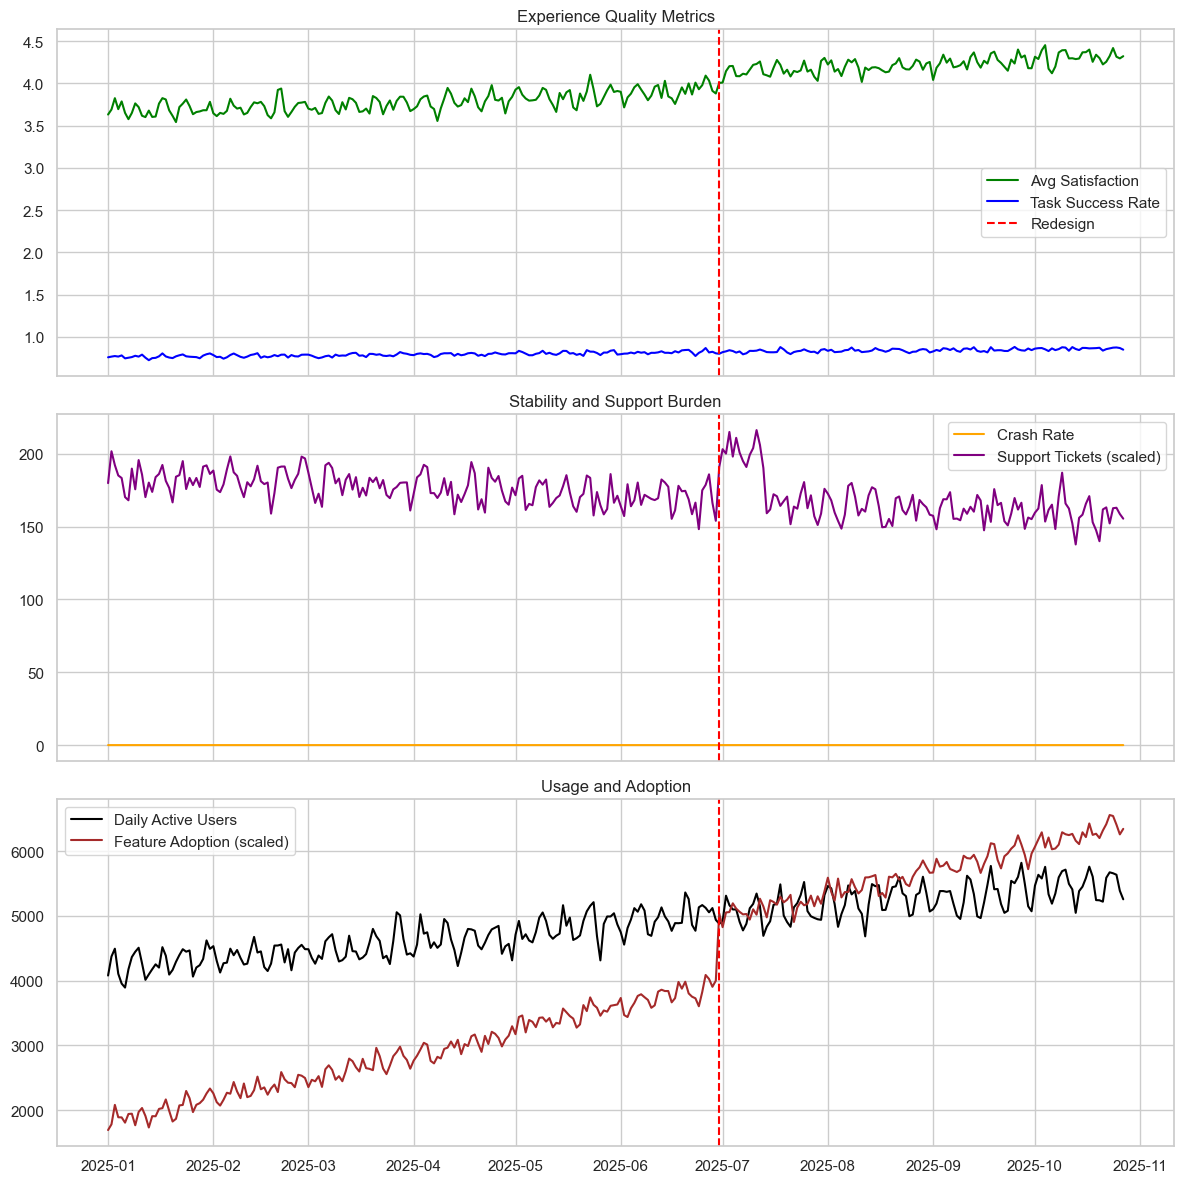

In [41]:

# How did UX metrics evolve over time around a redesign event?


from pathlib import Path

ts_csv = Path("ux_time_series_dataset.csv")
if not ts_csv.exists():
    raise FileNotFoundError("ux_time_series_dataset.csv not found. Ensure the file is in the notebook working directory.")

ux_ts_df = pd.read_csv(ts_csv)
ux_ts_df["date"] = pd.to_datetime(ux_ts_df["date"])
ux_ts_df = ux_ts_df.sort_values("date").reset_index(drop=True)

# Keep these constants explicit for downstream intervention analysis.
redesign_day = 180
release_window = 14

print("Loaded:", ts_csv.resolve())
print("Shape:", ux_ts_df.shape)
display(ux_ts_df.head())

# Plot key metrics over time with redesign marker.
fig, ax = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
ax[0].plot(ux_ts_df["date"], ux_ts_df["avg_satisfaction"], label="Avg Satisfaction", color="green")
ax[0].plot(ux_ts_df["date"], ux_ts_df["task_success_rate"], label="Task Success Rate", color="blue")
ax[0].axvline(ux_ts_df.loc[redesign_day, "date"], color="red", linestyle="--", label="Redesign")
ax[0].set_title("Experience Quality Metrics")
ax[0].legend()

ax[1].plot(ux_ts_df["date"], ux_ts_df["crash_rate"], label="Crash Rate", color="orange")
ax[1].plot(ux_ts_df["date"], ux_ts_df["support_tickets"], label="Support Tickets (scaled)", color="purple")
ax[1].axvline(ux_ts_df.loc[redesign_day, "date"], color="red", linestyle="--")
ax[1].set_title("Stability and Support Burden")
ax[1].legend()

ax[2].plot(ux_ts_df["date"], ux_ts_df["daily_active_users"], label="Daily Active Users", color="black")
ax[2].plot(ux_ts_df["date"], ux_ts_df["feature_adoption_rate"] * 10000, label="Feature Adoption (scaled)", color="brown")
ax[2].axvline(ux_ts_df.loc[redesign_day, "date"], color="red", linestyle="--")
ax[2].set_title("Usage and Adoption")
ax[2].legend()

plt.tight_layout()
plt.show()


In [42]:

ux_ts_df["date"] = pd.to_datetime(ux_ts_df["date"])
ux_ts_df = ux_ts_df.sort_values("date").reset_index(drop=True)

print("Missing values per column:")
display(ux_ts_df.isna().sum().to_frame("missing_count").T)

date_diffs = ux_ts_df["date"].diff().dropna().dt.days
print("Unique day gaps in date index:", sorted(date_diffs.unique()))
print("Rows:", len(ux_ts_df), "Date range:", ux_ts_df["date"].min().date(), "to", ux_ts_df["date"].max().date())

Missing values per column:


,date,daily_active_users,avg_satisfaction,task_success_rate,avg_completion_time,crash_rate,support_tickets,feature_adoption_rate,bounce_rate,retention_proxy
missing_count,0,0,0,0,0,0,0,0,0,0


Unique day gaps in date index: [np.int64(1)]
Rows: 300 Date range: 2025-01-01 to 2025-10-27


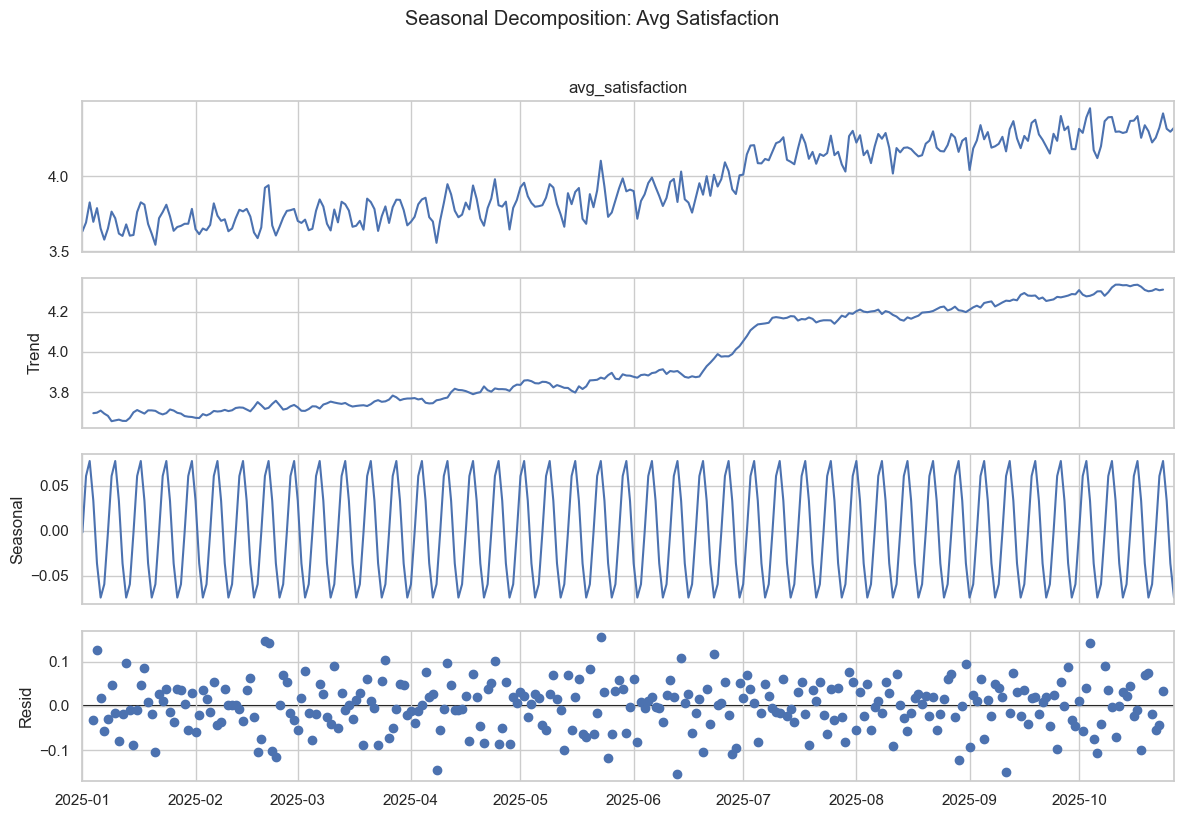

Lag/Rolling feature preview:


,daily_active_users,dau_lag_7,dau_roll7
date,,,
2025-01-01,4079.600864,NaN,NaN
2025-01-02,4373.107202,NaN,NaN
2025-01-03,4493.767365,NaN,NaN
2025-01-04,4106.504416,NaN,NaN
2025-01-05,3954.885682,NaN,NaN
2025-01-06,3893.093813,NaN,NaN
2025-01-07,4175.331455,NaN,4153.755828
2025-01-08,4365.030397,4079.600864,4194.531476
2025-01-09,4446.494984,4373.107202,4205.015445


Forecast MAE:  98.73
Forecast RMSE: 125.40
Forecast MAPE: 1.84%


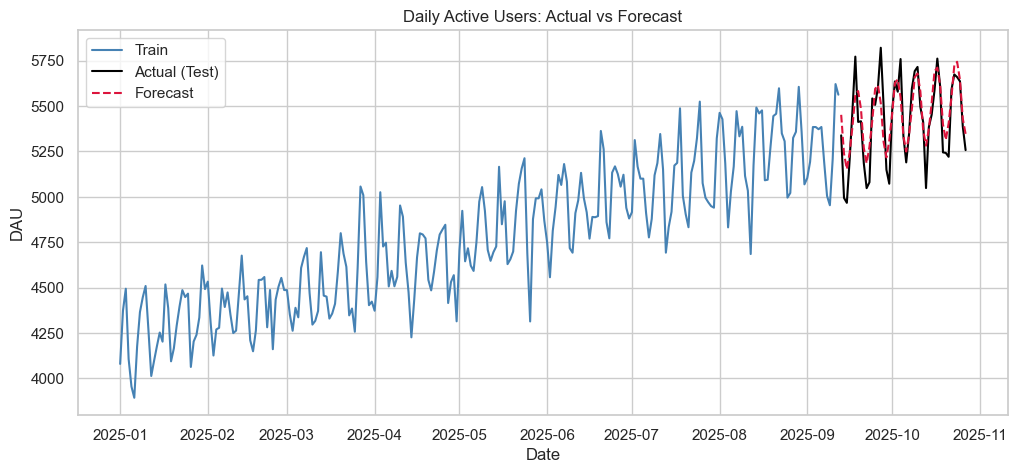


Simple redesign impact snapshot (30 days before vs after):


,metric,pre_30d_mean,post_30d_mean,difference_post_minus_pre
0,avg_satisfaction,3.9094,4.1434,0.2341
1,avg_completion_time,137.8230,127.3779,-10.4451
2,crash_rate,0.0227,0.0272,0.0045
3,support_tickets,169.4171,181.9995,12.5825
4,feature_adoption_rate,0.3768,0.5132,0.1364


In [43]:

# Lower MAE/RMSE means better forecast quality; inspect forecast plot for practical fit.


ts = ux_ts_df.set_index("date").copy()

# Decompose one metric for teaching trend + seasonality + residual ideas.
decomp = seasonal_decompose(ts["avg_satisfaction"], model="additive", period=7)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Seasonal Decomposition: Avg Satisfaction", y=1.02)
plt.tight_layout()
plt.show()
# Interpretation tip:
# - Trend line shows long-term movement.
# - Seasonal component shows repeating weekly pattern.
# - Residual spikes can indicate unusual events worth investigation.

# Create simple rolling and lag features for exploratory interpretation.
ts["dau_lag_7"] = ts["daily_active_users"].shift(7)
ts["dau_roll7"] = ts["daily_active_users"].rolling(7).mean()
print("Lag/Rolling feature preview:")
display(ts[["daily_active_users", "dau_lag_7", "dau_roll7"]].head(12))
# Interpretation tip:
# If DAU aligns with 7-day lag, a strong weekly cycle likely exists.

# Time-aware split: final 45 days as test.
test_size = 45
train_series = ts["daily_active_users"].iloc[:-test_size]
test_series = ts["daily_active_users"].iloc[-test_size:]

# Forecast with Holt-Winters Exponential Smoothing.
hw_model = ExponentialSmoothing(
    train_series,
    trend="add",
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated",
).fit(optimized=True)

forecast = hw_model.forecast(test_size)

mae = mean_absolute_error(test_series, forecast)
rmse = np.sqrt(mean_squared_error(test_series, forecast))
mape = np.mean(np.abs((test_series - forecast) / test_series)) * 100

print(f"Forecast MAE:  {mae:,.2f}")
print(f"Forecast RMSE: {rmse:,.2f}")
print(f"Forecast MAPE: {mape:.2f}%")
# Interpretation tip:
# Lower values indicate better forecast fit; MAPE is easy to explain as average percent error.

# Visual: actual vs forecast.
plt.figure(figsize=(12, 5))
plt.plot(train_series.index, train_series, label="Train", color="steelblue")
plt.plot(test_series.index, test_series, label="Actual (Test)", color="black")
plt.plot(forecast.index, forecast, label="Forecast", color="crimson", linestyle="--")
plt.title("Daily Active Users: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("DAU")
plt.legend()
plt.show()
# Interpretation tip:
# A close overlap between black and dashed red lines means the model captures short-term dynamics well.

# Simple intervention comparison: pre/post redesign means.
pre_window = ts.iloc[redesign_day-30:redesign_day]
post_window = ts.iloc[redesign_day:redesign_day+30]

intervention_summary = pd.DataFrame({
    "metric": ["avg_satisfaction", "avg_completion_time", "crash_rate", "support_tickets", "feature_adoption_rate"],
    "pre_30d_mean": [
        pre_window["avg_satisfaction"].mean(),
        pre_window["avg_completion_time"].mean(),
        pre_window["crash_rate"].mean(),
        pre_window["support_tickets"].mean(),
        pre_window["feature_adoption_rate"].mean(),
    ],
    "post_30d_mean": [
        post_window["avg_satisfaction"].mean(),
        post_window["avg_completion_time"].mean(),
        post_window["crash_rate"].mean(),
        post_window["support_tickets"].mean(),
        post_window["feature_adoption_rate"].mean(),
    ],
})
intervention_summary["difference_post_minus_pre"] = (
    intervention_summary["post_30d_mean"] - intervention_summary["pre_30d_mean"]
)

print("\nSimple redesign impact snapshot (30 days before vs after):")
display(intervention_summary.round(4))
# Interpretation tip:
# Positive/negative differences should be judged by metric directionality:
# - Higher is better for satisfaction/adoption.
# - Lower is better for completion time, crash rate, and support tickets.



- Time-aware analysis is essential for product UX metrics.
- Decomposition helps explain trend vs seasonality.
- Forecasting helps teams plan and detect when current behavior diverges from expected baselines.